# Combining scDNA + scRNA: reconstructing subclones from expression

The two production single-cell modalities see the *same* tumour through different windows: **scDNA**
reads copy number directly, **scRNA** reads expression. The clinical trick (clonealign, inferCNV,
Numbat) is to use the **DNA-defined copy-number profiles** to make sense of the **RNA** — because a
copy-number change *doses* the genes it spans, so a subclone's CN signature leaks into its expression.

This notebook shows that link is **emergent, not imposed**. We take the shared spatially-structured
tumour (`base_sim`), assay it with both modalities from the same cells, and show that the CN→expression
dosage relationship *falls out of the biology*. iscc alone supplies the two pieces no real dataset has:
the **true clone label** and the **true copy number** — so we can score a from-scratch reconstruction.

**The dataset is a mixture.** As in any real study, the sample is malignant cells **plus
microenvironment** (epithelial / stromal). We never filter to cancer up front — separating malignant
from normal is the *first analysis step*, and the normal cells are the diploid reference the whole
method leans on.

> The production tools do this properly — see `validation/validate_clonealign.py`,
> `validation/validate_infercnv.py`, `validation/validate_numbat.py`. Here we do a self-contained
> numpy/sklearn version to expose the *emergent signal* those tools exploit.

In [1]:
%matplotlib inline
import os, sys
sys.path.insert(0, os.path.abspath("."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import base_sim as B
from iscc.data import scRNA, scDNA

## 1. Grow the tumour and assemble a realistic mixture

We grow the shared multi-focal **DCIS→IDC ductal field** (≥10k cancer cells in a mixed field of glands
and stroma), then build the **assayed sample**: a subsample of malignant cells + a subsample of the
microenvironment. The raw section is majority normal (the stroma dominates by area); subsampling to a
few hundred cells at each end brings a plausible ~50% purity while keeping the normal compartment
present as the diploid reference.

In [2]:
t = B.grow_base_tumor()
cd = t.cell_data
types = B.cell_types(t)
idx = np.asarray(cd["cell_type"].index)
is_cancer_all = types == "cancer"
print(f"grown field: {len(types):,} cells  |  malignant {is_cancer_all.sum():,}   "
      f"microenvironment {(~is_cancer_all).sum():,}   raw purity {is_cancer_all.mean():.1%}")

# assemble the MIXTURE the assays consume: ~400 malignant + ~350 microenvironment (~53% purity)
rng = np.random.default_rng(0)
cancer_pool = idx[is_cancer_all]
normal_pool = idx[np.isin(types, ("epithelial", "stromal"))]
cancer_cells = list(rng.choice(cancer_pool, size=400, replace=False))
normal_cells = list(rng.choice(normal_pool, size=350, replace=False))
mixture = cancer_cells + normal_cells
type_map = dict(zip(idx, types))
print(f"assayed mixture: {len(mixture)} cells  |  purity {len(cancer_cells)/len(mixture):.0%}  "
      f"({len(cancer_cells)} malignant + {len(normal_cells)} microenvironment)")

grown field: 30,616 cells  |  malignant 10,132   microenvironment 20,484   raw purity 33.1%
assayed mixture: 750 cells  |  purity 53%  (400 malignant + 350 microenvironment)


## 2. The spatial structure — multi-focal

The tumour is a **field of glands** (walls drawn) in stroma. Left: cells by true type — cancer fills
several gland lumens (multi-focal DCIS) and breaches into the stroma. Right: the malignant cells
coloured by **which gland** they colonised (`cell_gland`; stroma-invaded cancer in black) — every focus
traces to one founder. The assayed cells (circled, left) are drawn from across that structure,
malignant and normal alike.

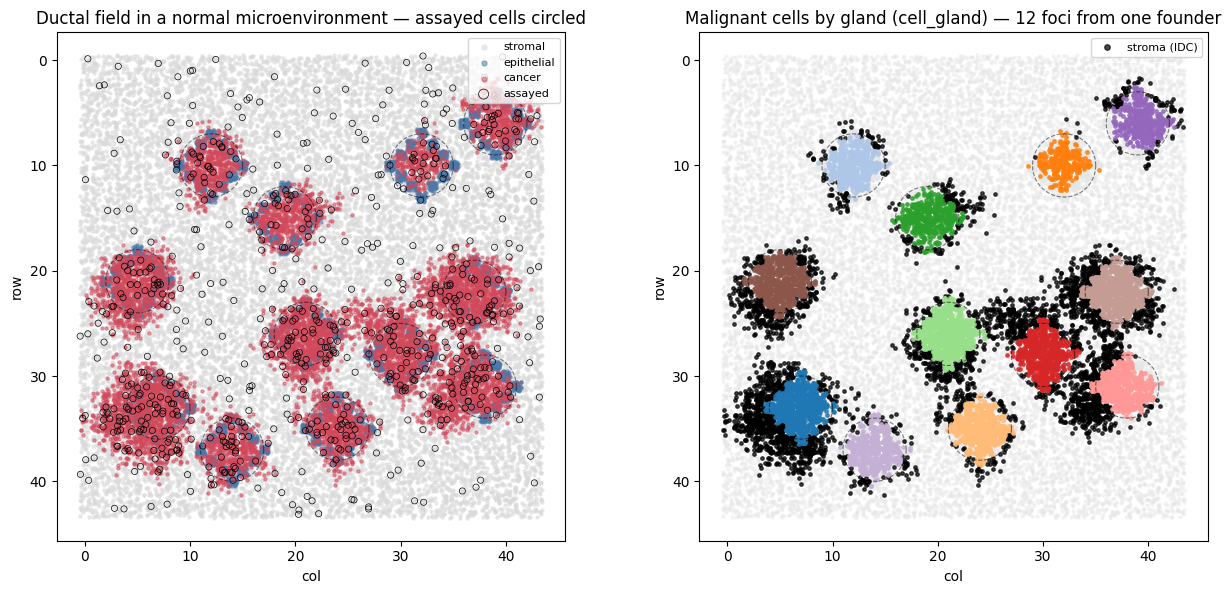

In [3]:
crd = cd["cell_crd"]
jit = np.random.default_rng(1)
jx = crd["col"].values + jit.uniform(-0.45, 0.45, len(crd))
jy = crd["row"].values + jit.uniform(-0.45, 0.45, len(crd))
pos = {c: i for i, c in enumerate(idx)}
mix_pos = np.array([pos[c] for c in mixture])
gland = B.cell_gland(t)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
palette = {"stromal": "0.85", "epithelial": "#4c78a8", "cancer": "#d1495b"}
for name, col in palette.items():
    m = types == name
    axes[0].scatter(jx[m], jy[m], s=5, c=col, alpha=0.5, label=f"{name}")
axes[0].scatter(jx[mix_pos], jy[mix_pos], s=20, facecolors="none",
                edgecolors="k", lw=0.5, label="assayed")
B.draw_glands(axes[0], t)
axes[0].set_aspect("equal"); axes[0].invert_yaxis()
axes[0].legend(fontsize=8, markerscale=1.6, loc="upper right")
axes[0].set_title("Ductal field in a normal microenvironment — assayed cells circled")
axes[0].set_xlabel("col"); axes[0].set_ylabel("row")

# malignant cells coloured by which gland they colonised (stroma-invaded = black)
cmap = plt.get_cmap("tab20")
mc = types == "cancer"
gvals = gland[mc]
axes[1].scatter(jx[~mc], jy[~mc], s=4, c="0.9", alpha=0.4)
axes[1].scatter(jx[mc][gvals == -1], jy[mc][gvals == -1], s=6, c="k", alpha=0.7, label="stroma (IDC)")
for g in sorted(set(gvals[gvals >= 0])):
    m = gvals == g
    axes[1].scatter(jx[mc][m], jy[mc][m], s=6, color=cmap(int(g) % 20), alpha=0.8)
B.draw_glands(axes[1], t)
axes[1].set_aspect("equal"); axes[1].invert_yaxis()
axes[1].legend(fontsize=8, markerscale=1.6, loc="upper right")
axes[1].set_title(f"Malignant cells by gland (cell_gland) — {len(B.glands_colonised(t))} foci from one founder")
axes[1].set_xlabel("col"); axes[1].set_ylabel("row")
plt.tight_layout()

## 3. scRNA the mixture — malignant vs normal separate on their own

Run the scRNA assay on the mixture and embed it (PCA). **Separating malignant from normal is the real
first step of any tumour scRNA pipeline** — and it works from expression alone: an unsupervised
2-cluster split recovers the true malignant/normal partition. The normal cells are not noise to be
discarded; they are the diploid reference the copy-number reasoning below depends on.

malignant vs normal separate in expression space: 2-means ARI = 0.81


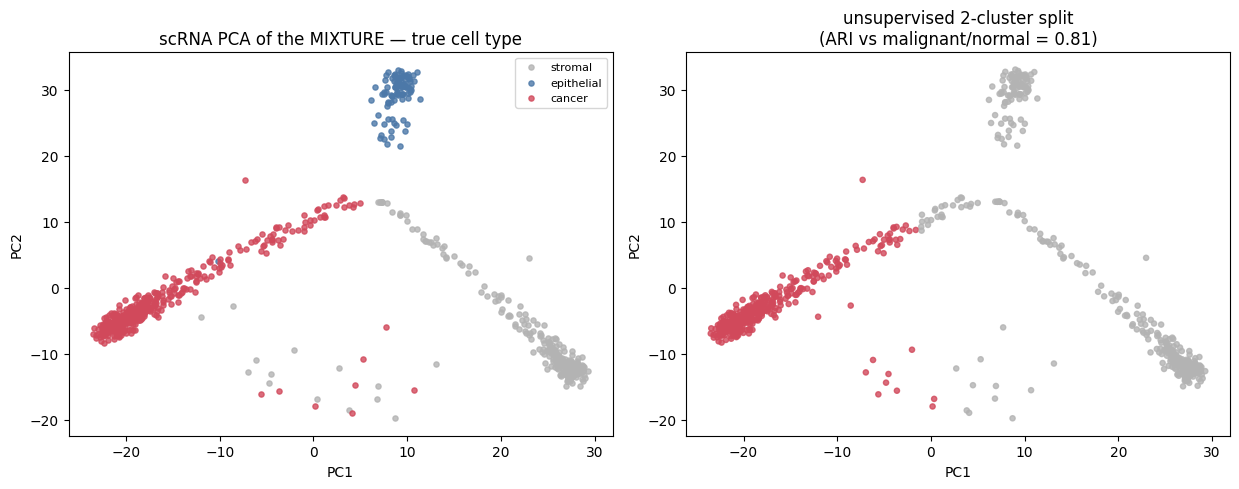

In [4]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

rna = scRNA(n_cells=len(mixture), protocol="10x", seed=1).run(cd, cell_subset=mixture)
Y = rna.observed_counts
rna_cells = list(Y.index)
is_mal = np.isin(rna_cells, cancer_cells)
type_of = np.array([type_map[c] for c in rna_cells])

Yv = Y.values.astype(float)
lib = Yv.sum(1, keepdims=True)
Ycpm = Yv / np.where(lib > 0, lib, 1.0) * 1e4
Ylog = np.log1p(Ycpm)
pcs = PCA(n_components=10, random_state=0).fit_transform(Ylog - Ylog.mean(0))
km = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(pcs)
ari = adjusted_rand_score(is_mal, km)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
for name, col in {"stromal": "0.7", "epithelial": "#4c78a8", "cancer": "#d1495b"}.items():
    m = type_of == name
    axes[0].scatter(pcs[m, 0], pcs[m, 1], s=14, c=col, alpha=0.8, label=name)
axes[0].legend(fontsize=8); axes[0].set_title("scRNA PCA of the MIXTURE — true cell type")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[1].scatter(pcs[:, 0], pcs[:, 1], s=14, alpha=0.8,
                c=["#d1495b" if k else "0.7" for k in km])
axes[1].set_title(f"unsupervised 2-cluster split\n(ARI vs malignant/normal = {ari:.2f})")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout()
print(f"malignant vs normal separate in expression space: 2-means ARI = {ari:.2f}")

## 4. DNA defines the clones

Within the malignant cells (identified above), we define subclones from their **per-segment copy
number** — the standard clonealign setup, where clones and their integer CN profiles come from the DNA
modality. Agglomerative clustering on the segment-CN vectors gives a handful of clones, each with a
distinct amplification / loss.

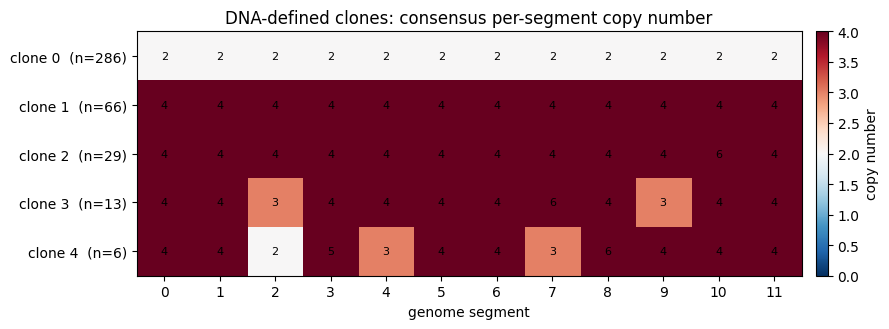

In [5]:
from sklearn.cluster import AgglomerativeClustering

seg, gene_seg = B.segment_cn(t)          # (cells x n_seg) total CN, and per-gene->segment map
cpos = np.array([pos[c] for c in cancer_cells])
seg_cancer = seg[cpos]                    # per-segment CN of the malignant cells
K = 5
lab = AgglomerativeClustering(n_clusters=K).fit_predict(seg_cancer)
consensus = np.stack([np.rint(seg_cancer[lab == k].mean(0)) for k in range(K)]).astype(int)
clone_of = dict(zip(cancer_cells, lab))

fig, ax = plt.subplots(figsize=(9, 3.4))
im = ax.imshow(consensus, cmap="RdBu_r", vmin=0, vmax=4, aspect="auto")
ax.set_yticks(range(K)); ax.set_yticklabels([f"clone {k}  (n={int((lab==k).sum())})" for k in range(K)])
ax.set_xlabel("genome segment"); ax.set_xticks(range(t.n_segments))
ax.set_title("DNA-defined clones: consensus per-segment copy number")
for k in range(K):
    for s in range(t.n_segments):
        ax.text(s, k, int(consensus[k, s]), ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="copy number")
plt.tight_layout()

## 5. scDNA recovers those copy-number profiles

The clone CN profiles clonealign consumes must be ones the **DNA modality actually supports**. We run
scDNA on the mixture and use the **normal cells as the diploid (CN = 2) reference** — the job the
microenvironment does in every real CNA caller. Coverage recovers the **relative** copy-number
*profile* of each clone faithfully (high per-clone correlation); note it does *not* pin the **absolute
ploidy** — this tumour is largely whole-genome-doubled, and coverage alone cannot see a balanced
doubling. That takes the allele layer — the subject of [`wgd_allele_cna`](wgd_allele_cna.ipynb).
(We use a deep DLP+-like regime, `mu_depth=200, kappa=200`; the lumpy low-`kappa` default and its ADO
artifacts are in [`assay_dna`](assay_dna.ipynb).)

scDNA per-clone copy-number profile correlation with the DNA-defined truth: nan


/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/var/folders/d4/tfj5y66n2zzddb2k40xhyhk80000gp/T/ipykernel_57346/1357662521.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


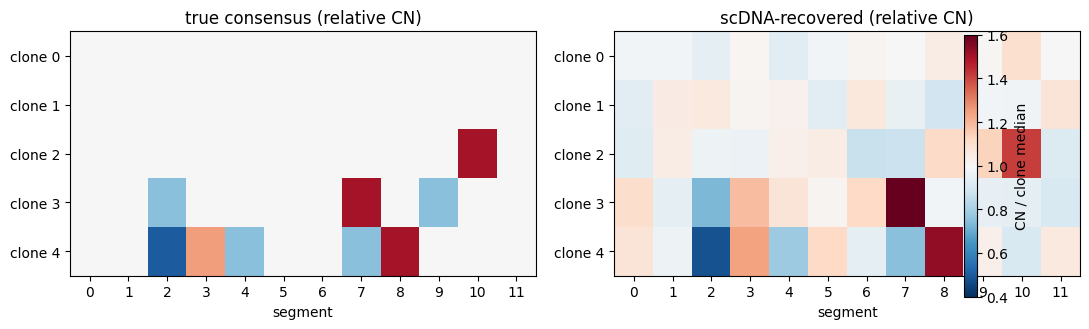

In [6]:
dna_cells = cancer_cells + normal_cells
dna = scDNA(n_cells=len(dna_cells), breadth="wgs", seed=7,
            mu_depth=200.0, kappa=200.0).run(cd, cell_subset=dna_cells)
seg_ids = np.array([int(g.split("_")[1]) for g in dna.genes])   # gene "G_<seg>_<i>" -> seg
cov = dna.coverage.values.astype(float)
seg_cov = np.stack([cov[:, seg_ids == s].mean(1) for s in range(t.n_segments)], axis=1)
is_norm = np.isin(dna.cells, normal_cells)
baseline = seg_cov[is_norm].mean(0)                         # the diploid (CN=2) normal reference
obs_cn = 2.0 * seg_cov / np.where(baseline > 0, baseline, 1.0)

is_can = np.isin(dna.cells, cancer_cells)
dna_lab = np.array([clone_of[c] for c in dna.cells[is_can]])
recovered = np.stack([np.median(obs_cn[is_can][dna_lab == k], axis=0) for k in range(K)])
# score on the RELATIVE profile (coverage sees relative CN, not absolute ploidy) — per-clone correlation
rel = lambda M: M / np.median(M, axis=1, keepdims=True)
prof_corr = np.mean([np.corrcoef(recovered[k], consensus[k])[0, 1] for k in range(K)])
print(f"scDNA per-clone copy-number profile correlation with the DNA-defined truth: {prof_corr:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, mat, title in zip(axes, [rel(consensus.astype(float)), rel(recovered)],
                          ["true consensus (relative CN)", "scDNA-recovered (relative CN)"]):
    im = ax.imshow(mat, cmap="RdBu_r", vmin=0.4, vmax=1.6, aspect="auto")
    ax.set_yticks(range(K)); ax.set_yticklabels([f"clone {k}" for k in range(K)])
    ax.set_xlabel("segment"); ax.set_xticks(range(t.n_segments)); ax.set_title(title)
plt.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="CN / clone median")
plt.tight_layout()

## 6. The emergent CN → expression link

Nothing in the assay ties expression to copy number by hand — yet a **dosage** relationship falls out of
the per-allele expression model. The cleanest way to see it (and the way inferCNV works) is at the level
of a **clone's whole copy-number profile**: express each segment **relative to the normal cells**, and
compare each clone's *shape* across segments to its true CN profile. Below, the DNA-defined CN profile
(left) and the RNA relative-expression profile (right) are placed side by side — the per-clone rank
correlation (Spearman) measures how well the RNA *shape* follows the DNA one.

Be warned this is a **faint** signal: at single-cell 10x depth, with library-size normalisation and the
expression-program layer both diluting per-gene dosage, the per-clone RNA profile tracks CN only weakly
(mean ρ of order ~0.1, and negative for a clone or two). Reading copy number cleanly from RNA is *hard*
— which is the honest lesson here, and why the production callers (inferCNV/Numbat) lean on allele
information and careful count models rather than raw dosage. §7 shows even this faint signal
reconstructs clones **above chance**.

/var/folders/d4/tfj5y66n2zzddb2k40xhyhk80000gp/T/ipykernel_57346/3873223972.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  per_clone_rho = [spearmanr(clone_rna[k], consensus[k]).correlation for k in range(K)]


mean per-clone Spearman(RNA relative-expression profile, CN profile) = 0.19
per-clone: [nan, nan, -0.22, 0.37, 0.43]


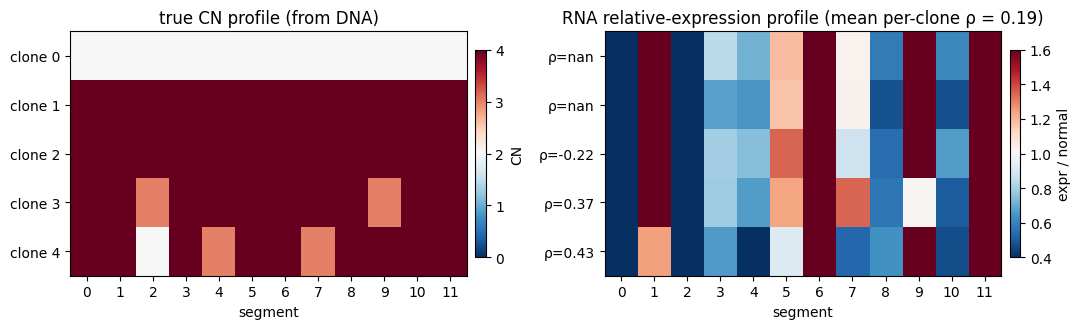

In [7]:
from scipy.stats import spearmanr

# assayed per-segment expression + clone label, reused by the RNA-only reconstruction in §7
gi = {g: i for i, g in enumerate(list(cd["cell_exp"].columns))}
gseg = np.array([gene_seg[gi[g]] for g in Y.columns])
segexp = np.stack([Ycpm[:, gseg == s].mean(1) for s in range(t.n_segments)], axis=1)
rna_clone = np.array([clone_of.get(c, -1) for c in rna_cells])

# per-clone RNA relative-expression profile (vs the normal cells) and how it tracks the CN profile
norm_base = segexp[~is_mal].mean(0)
clone_rna = np.stack([segexp[(rna_clone == k) & is_mal].mean(0) / np.where(norm_base > 0, norm_base, 1.0)
                      for k in range(K)])
per_clone_rho = [spearmanr(clone_rna[k], consensus[k]).correlation for k in range(K)]
rho = float(np.nanmean(per_clone_rho))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
im0 = axes[0].imshow(consensus, cmap="RdBu_r", vmin=0, vmax=4, aspect="auto")
axes[0].set_yticks(range(K)); axes[0].set_yticklabels([f"clone {k}" for k in range(K)])
axes[0].set_xlabel("segment"); axes[0].set_xticks(range(t.n_segments))
axes[0].set_title("true CN profile (from DNA)")
plt.colorbar(im0, ax=axes[0], fraction=0.025, pad=0.02, label="CN")
im1 = axes[1].imshow(clone_rna, cmap="RdBu_r", vmin=0.4, vmax=1.6, aspect="auto")
axes[1].set_yticks(range(K)); axes[1].set_yticklabels([f"ρ={r:.2f}" for r in per_clone_rho])
axes[1].set_xlabel("segment"); axes[1].set_xticks(range(t.n_segments))
axes[1].set_title(f"RNA relative-expression profile (mean per-clone ρ = {rho:.2f})")
plt.colorbar(im1, ax=axes[1], fraction=0.025, pad=0.02, label="expr / normal")
plt.tight_layout()
print(f"mean per-clone Spearman(RNA relative-expression profile, CN profile) = {rho:.2f}")
print("per-clone:", [round(float(r), 2) for r in per_clone_rho])

## 7. Reconstruct the clones from RNA alone

Now the payoff (clonealign's idea, stripped to its core): assign each **malignant** RNA cell to the
clone whose **DNA copy-number profile** best matches its per-segment expression. This uses *only* the
RNA counts plus the DNA-defined CN profiles — never the true RNA-cell clone label — and we score it
against that held-out truth.

clone reconstructed from RNA alone (nearest DNA CN profile): accuracy 45%   (chance 20%)   ARI -0.02


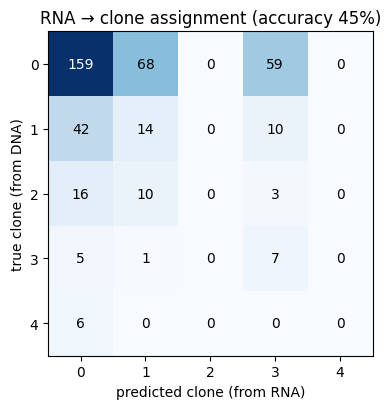

In [8]:
from scipy.optimize import linear_sum_assignment

mal_pos = np.where(is_mal)[0]
pred = []
for i in mal_pos:
    cors = [np.corrcoef(segexp[i], consensus[k])[0, 1] for k in range(K)]
    pred.append(int(np.nanargmax(cors)))
pred = np.array(pred)
truth = rna_clone[mal_pos]

M = np.zeros((K, K))
for a in range(K):
    for b in range(K):
        M[a, b] = ((truth == a) & (pred == b)).sum()
r_, c_ = linear_sum_assignment(-M)
remap = {c_[i]: r_[i] for i in range(len(r_))}
pred_m = np.array([remap.get(p, p) for p in pred])
acc = (pred_m == truth).mean()
ari2 = adjusted_rand_score(truth, pred)
print(f"clone reconstructed from RNA alone (nearest DNA CN profile): "
      f"accuracy {acc:.0%}   (chance {1/K:.0%})   ARI {ari2:.2f}")

CM = np.zeros((K, K), int)
for tr, pr in zip(truth, pred_m):
    CM[tr, pr] += 1
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(CM, cmap="Blues")
for a in range(K):
    for b in range(K):
        ax.text(b, a, CM[a, b], ha="center", va="center",
                color="white" if CM[a, b] > CM.max() / 2 else "black")
ax.set_xlabel("predicted clone (from RNA)"); ax.set_ylabel("true clone (from DNA)")
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_title(f"RNA → clone assignment (accuracy {acc:.0%})")
plt.tight_layout()

## What this shows

* One spatially-structured tumour, assayed by **scDNA and scRNA from the same cells**, gives a
  labelled multi-modal benchmark: true clone, true CN, and both observed modalities.
* The **CN → expression dosage link is emergent** — a consequence of the per-allele expression model,
  not something the assay imposes — the signal clonealign / inferCNV / Numbat exploit. But at single-cell
  depth it is **faint**: per-gene dosage is diluted by library-size normalisation and the program layer,
  so reading CN from RNA is genuinely hard (the honest lesson of §6).
* A bare-bones nearest-CN-profile reconstruction still assigns malignant RNA cells to their DNA-defined
  clone **above chance** — a deliberately *simple* floor on that faint signal, **not** a tool result. The
  production methods (which model the count distribution, the library size, allele information, and a
  phylogeny prior) do better; that gap is the point.

**Next / see also:**
[`base_simulation`](base_simulation.ipynb) (the shared tumour) ·
[`wgd_allele_cna`](wgd_allele_cna.ipynb) (whole-genome doubling + the allele layer) ·
[`assay_dna`](assay_dna.ipynb) / [`assay_scrna`](assay_scrna.ipynb) (the assay models in depth) ·
the real tool benchmarks under `validation/` (`validate_clonealign.py`, `validate_infercnv.py`,
`validate_numbat.py`).